In [1]:
import warnings
warnings.filterwarnings(action='ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_finance import candlestick_ohlc
import matplotlib.dates as mdates
import pyupbit

/root/miniforge3/envs/finance/lib/python3.9/site-packages/mpl_finance.py:16: DeprecationWarning: 



    Please use `mplfinance` instead (no hyphen, no underscore).

    To install: `pip install --upgrade mplfinance` 

   For more information, see: https://pypi.org/project/mplfinance/


  __warnings.warn('\n\n  ================================================================='+


In [31]:
COUNT = 300
REFERENCE = pyupbit.get_ohlcv("KRW-BTC", count=COUNT)
original_samples = dict()
for ticker in pyupbit.get_tickers(fiat="KRW"):
    sample = pyupbit.get_ohlcv(ticker, count=COUNT)
    
    if len(sample) < 220:
        continue
    
    # preprocess
    sample["WPR"] = -1.*(sample['high'].rolling(14).max() - sample['close'])/(sample['high'].rolling(14).max() - sample['low'].rolling(14).min())
    sample['TP'] = (sample['high']+sample['low']+sample['close'])/3.
    sample['PMF'] = 0.; sample['NMF'] = 0.
    for idx in sample.index:
        if sample.shift(1).loc[idx, 'TP'] < sample.loc[idx, 'TP']:
            sample.loc[idx, 'PMF'] = sample.loc[idx, 'TP'] * sample.loc[idx, 'volume']
        else:
            sample.loc[idx, 'NMF'] = sample.loc[idx, 'TP'] * sample.loc[idx, 'volume']
    sample['MFI'] = sample['PMF'].rolling(window=10).sum() / (sample['PMF'].rolling(window=10).sum() + sample['NMF'].rolling(window=10).sum())
    sample['noise'] = 1. - abs(sample['close'] - sample['open'])/(sample['high'] - sample['low'])
    sample['noise20'] = sample['noise'].rolling(window=20).mean()
    sample['momentum'] = (sample['close'] - sample.shift(10)['close'])/sample.shift(10)['close']
    sample['return'] = 1. + sample['close'].pct_change()
    sample['reward'] = 1. + sample['close'].pct_change()
    sample['total_reward'] = sample['reward'].cumprod()
    sample['log_reward'] = np.log(sample['reward'])
    sample.dropna(inplace=True)
    
    original_samples[ticker] = sample.copy(); del sample

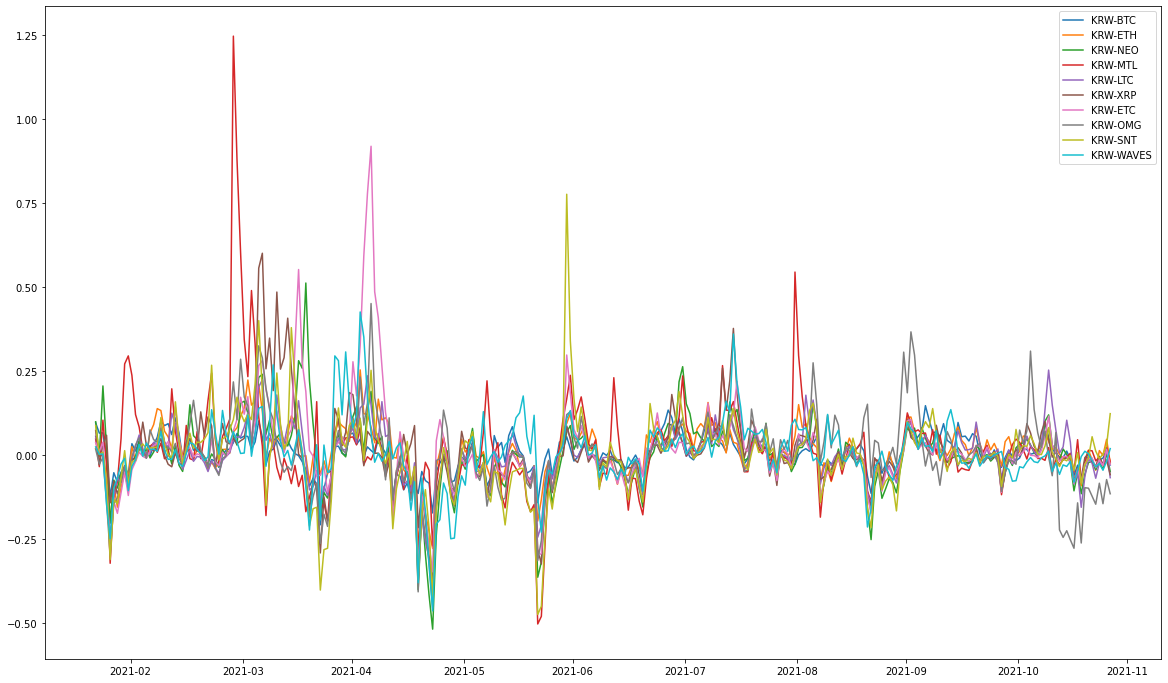

In [32]:
# make value functions
samples = dict()
for coin in original_samples.keys():
    sample = original_samples[coin].copy()
    sample['value'] = 0.
    
    for idx in sample.index:
        if idx == sample.index[0]:
            sample.loc[idx, 'value'] = sample.loc[idx, 'log_reward']
            continue
        
        # log_rtn = sample.loc[idx, 'log_reward'] if sample.loc[idx, 'momentum'] > 0. else 0.
        log_rtn = sample.loc[idx, 'log_reward']
        gamma = 1. - 0.5*sample.loc[idx, 'noise']
        sample.loc[idx, 'value'] = log_rtn + gamma*(sample.shift(1).loc[idx, 'value'])
    samples[coin] = sample

plt.figure(figsize=(20, 12))
for coin in list(samples.keys())[:10]:
    plt.plot(samples[coin].index, samples[coin].value, label=coin)
plt.legend(loc='best')
plt.show()

In [33]:
book = samples['KRW-BTC'][['close']].copy()
book['number'] = book.index.map(mdates.date2num)
book['reward'] = 1.
book['value'] = 0.

for idx in REFERENCE.index:
    if idx == REFERENCE.index[0]:
        continue
    
    # select 20 highest coins|
    volumes = dict()
    for coin in samples.keys(): 
        try:
            volumes[coin] = samples[coin].loc[idx, 'close'] * samples[coin].loc[idx, 'volume']
            #volumes[coin] = samples[coin].loc[idx, 'MFI']
        except:
            continue
    top20v = dict(sorted(volumes.items(), key=(lambda x: x[1]), reverse=True)[:20])
    
    # make dictionary for the values
    values = dict()
    for coin in top20v.keys():
        try:
            values[coin] = samples[coin].loc[idx, 'value']
        except:
            pass
        
    if len(values) == 0:
        continue
    
    res = dict(sorted(values.items(), key=(lambda x: x[1]), reverse=True)[:5])
    value = np.mean(list(res.values()))
    
    reward = 0.
    for i, coin in enumerate(res.keys()):
        ratio = 1./len(res)
        
        #if samples[coin].loc[idx, 'momentum'] < 0. or samples[coin].loc[idx, 'value'] < samples["BTCUSDT"].loc[idx, 'value']:
        if samples[coin].loc[idx, 'momentum'] < 0.3:
            reward += ratio
        else:
            reward += ratio*(samples[coin].shift(-1).loc[idx, 'return']-0.002)
        
    book.loc[idx, 'reward'] = reward
    book.loc[idx, 'value'] = value
book.dropna(inplace=True)
book.tail(25)

,close,number,reward,value
2021-11-01 09:00:00,72401000.0,18932.375,1.209492,0.369464
2021-11-02 09:00:00,74150000.0,18933.375,0.942647,0.485551
2021-11-03 09:00:00,74600000.0,18934.375,0.883481,0.275060
2021-11-04 09:00:00,73807000.0,18935.375,1.040179,0.211345
2021-11-05 09:00:00,74121000.0,18936.375,0.983849,0.218305
2021-11-06 09:00:00,74575000.0,18937.375,0.988062,0.175218
2021-11-07 09:00:00,76536000.0,18938.375,1.001941,0.126068
2021-11-08 09:00:00,81403000.0,18939.375,0.962802,0.177167
2021-11-09 09:00:00,80857000.0,18940.375,1.002197,0.158159
2021-11-10 09:00:00,79660000.0,18941.375,0.998975,0.073888


==== value trading ====
Accumulated Returns: 289.36 %
CAGR: 488.26 %
MDD: -71.85 %
VOL: 153.153 %
Sharpe: 24020.79 %


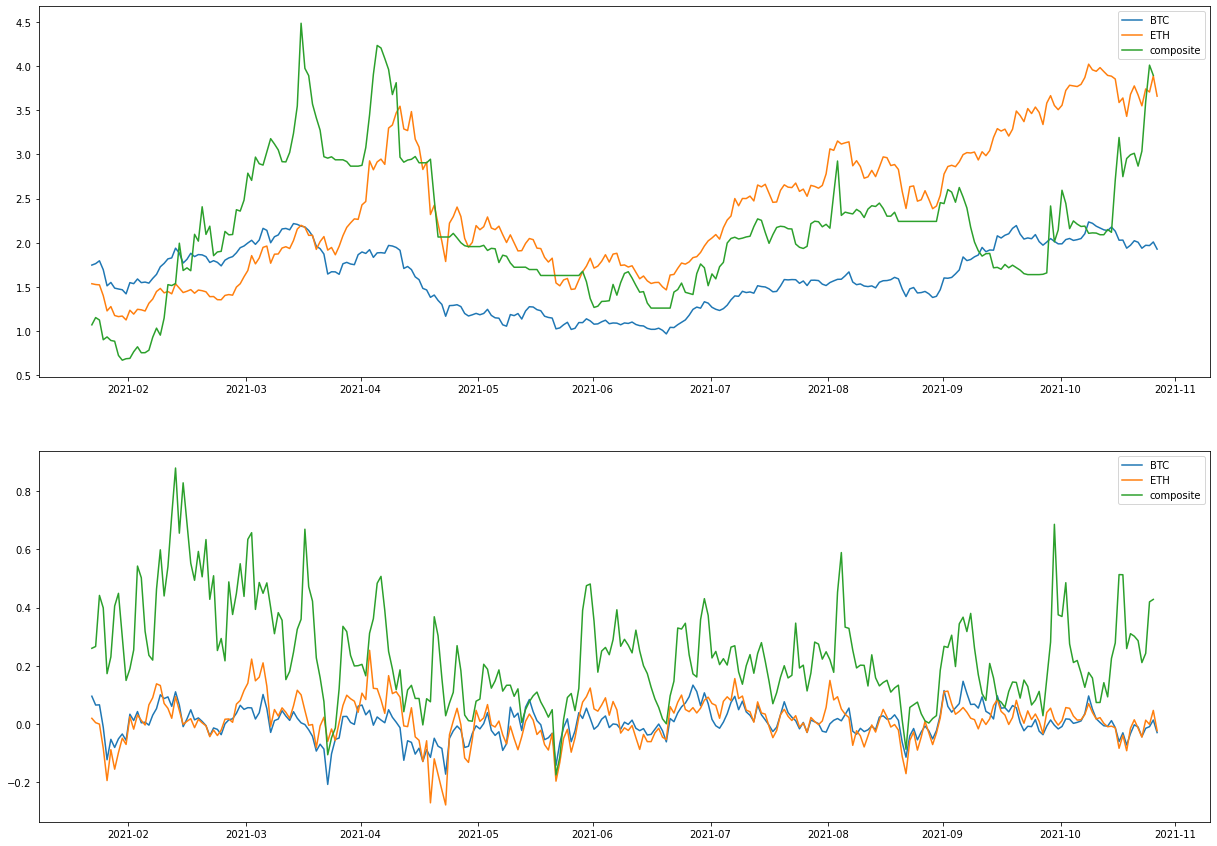

In [34]:
# evaluate
total_reward = 1.
for idx in book.index:
    total_reward *= book.loc[idx, 'reward']
    book.loc[idx, 'total_reward'] = total_reward
CAGR = book['total_reward'].iloc[-1]**(365./len(book.index)) - 1.

historical_max = book['total_reward'].cummax()
daily_drawdown = book['total_reward']/historical_max - 1.
historical_dd = daily_drawdown.cummin()
MDD = historical_dd.min()
VOL = np.std(book['reward'])*np.sqrt(365.)                                     # 주가의 변동폭은 시간의 제곱근에 비례
Sharpe = (np.mean(book['reward'])/np.std(book['reward'])*np.sqrt(365.))       # 연율화된 sharpe ratio # unacceptable

print("==== value trading ====")
print("Accumulated Returns:", round((total_reward-1.)*100, 2), "%")
print("CAGR:", round(CAGR*100, 2), "%")
print("MDD:", round(MDD*100, 2), "%")
print("VOL:", round(VOL*100, 3), "%")
print("Sharpe:", round(Sharpe*100,2), "%")

plt.figure(figsize=(21, 15))
plt.subplot(2, 1, 1)
#plt.yscale('log')
#for coin in samples.keys():
#    plt.plot(samples[coin].index, samples[coin].total_reward, label=coin)
plt.plot(samples['KRW-BTC'].index, samples['KRW-BTC'].total_reward, label="BTC")
plt.plot(samples['KRW-ETH'].index, samples['KRW-ETH'].total_reward, label="ETH")
plt.plot(book.index, book.total_reward, label='composite')
plt.legend(loc='best')

plt.subplot(2, 1, 2)
plt.plot(samples['KRW-BTC'].index, samples['KRW-BTC'].value, label="BTC")
plt.plot(samples['KRW-ETH'].index, samples['KRW-ETH'].value, label="ETH")
plt.plot(book.index, book.value, label="composite")
plt.legend(loc='best')

plt.show()